In [94]:
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import fbeta_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import shap

import utils
import hdbscan



sns.set_theme(style="whitegrid")
#f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

DATASET_PATH = "data/BRFSS2.csv"
TARGET = "Heart_Disease"

SEED = 42

In [3]:
# load dataset
X, y = utils.load_dataset(DATASET_PATH, TARGET)

# we use a hierarchical split
# 1. split the data in 80% train and 20% test
# 2. split the train again in 80% train and 20% val
feat_names = utils.feat_names(DATASET_PATH, TARGET)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

Metric     | 
Accuracy   | 0.7336    
Precision  | 0.2039    
Recall     | 0.7905    
F1-Score   | 0.3242    
F2-Score   | 0.5018    
AUPRC      | 0.3055    



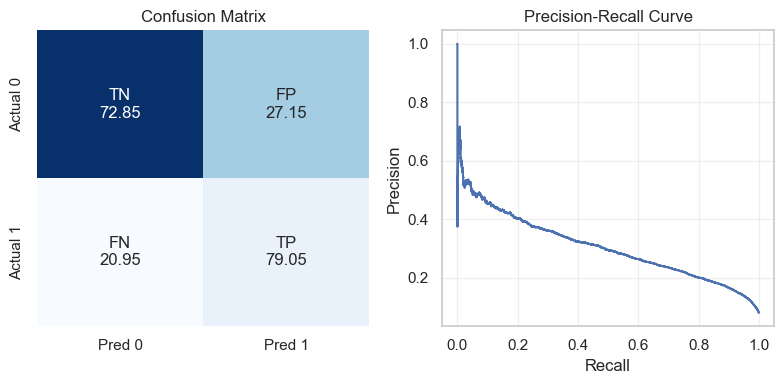

In [4]:
logreg_clf = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('clf', LogisticRegression(C=10, penalty="l2", class_weight="balanced", random_state=SEED, solver="saga"))
])

logreg_clf.fit(X_train, y_train)
y_val_probs = logreg_clf.predict_proba(X_val)[:, 1]
metrics, fig, _ = utils.compute_metrics(y_val, y_val_probs)
print(metrics)
plt.figure(fig.number)
plt.show()

# Leveraging Explainable AI

Since the logistic regression model achieved the best F2 score, we will use it from now on.

The idea is to leverage SHAP values to perform clustering in order to identify clinical phenotypes for which the model is unreliable. This information is crucial for understanding the model’s limitations, specifically determining when its predictions can be trusted and when they should be interpreted with caution.

This is particularly important in the medical field, identifying subgroups of patients associated with poor model reliability can support safer deployment, and help to recognize cases that may require additional validation or expert assessment

In [5]:
# going from the raw data manifold into the shap manifold
model = logreg_clf.named_steps['clf']
scaler = logreg_clf.named_steps['scaler']

X_train_scal = scaler.transform(X_train)
X_val_scal = scaler.transform(X_val)
X_test_scal = scaler.transform(X_test)

explainer = shap.LinearExplainer(model, X_train_scal)
shap_val = explainer(X_val_scal)
shap_val.feature_names = feat_names
shap_val_values = shap_val.values

shap_test = explainer(X_test_scal)
shap_test.feature_names = feat_names
shap_test_values = shap_test.values

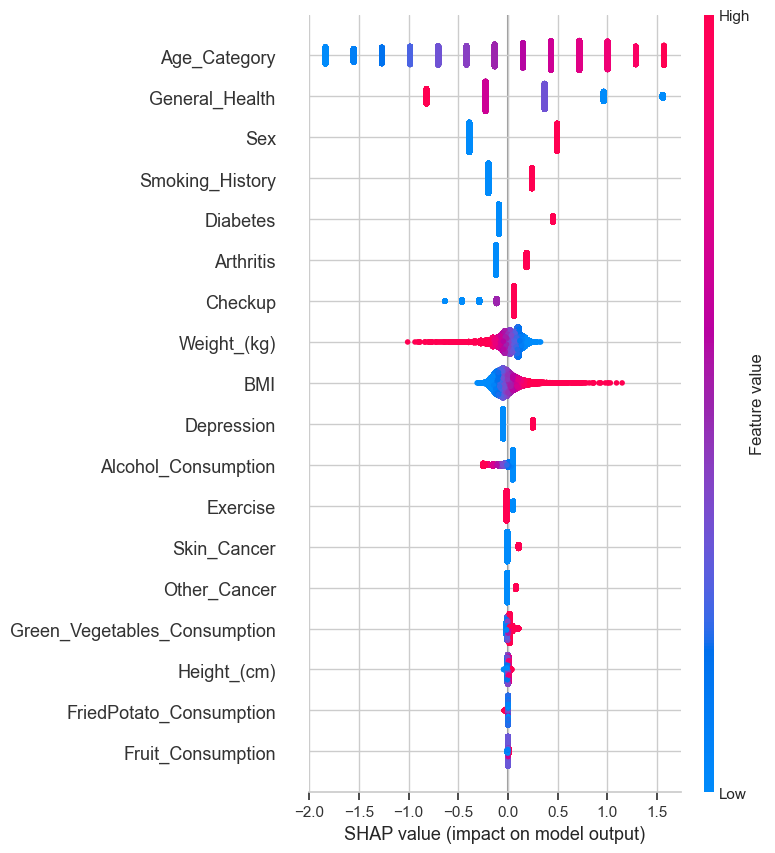

In [6]:
shap.summary_plot(shap_val, X_val_scal)

In [7]:
pca = PCA(n_components=2, random_state=SEED)
shap_val_values_2d = pca.fit_transform(shap_val_values)
shap_test_values_2d = pca.fit_transform(shap_test_values)

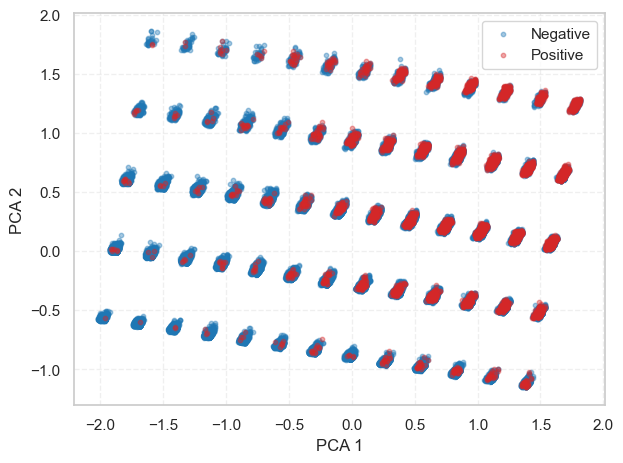

In [28]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
    shap_val_values_2d[y_val == 0, 0], shap_val_values_2d[y_val == 0, 1],
    color="tab:blue", alpha=0.4, s=10, label="Negative"
)

plt.scatter(
    shap_val_values_2d[y_val == 1, 0], shap_val_values_2d[y_val == 1, 1],
    color="tab:red", alpha=0.4, s=10, label="Positive" 
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True, linestyle="--", alpha=0.3)

plt.legend()

plt.tight_layout()
plt.show()

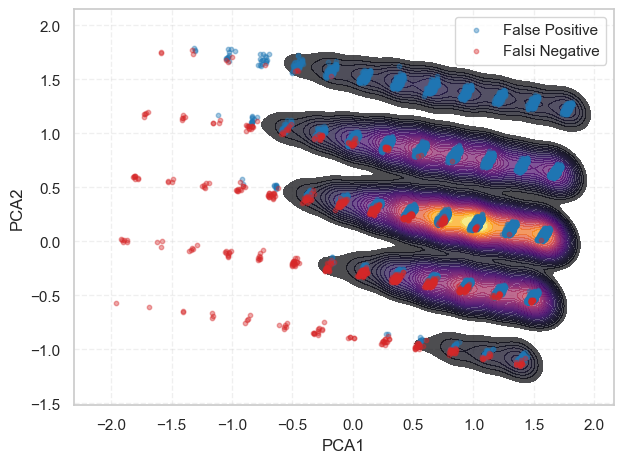

In [ ]:
y_val_pred = (y_val_probs >= 0.5).astype(int)

tn = (y_val == 0) & (y_val_pred == 0)
tp = (y_val == 1) & (y_val_pred == 1)
fp = (y_val == 0) & (y_val_pred == 1)
fn = (y_val == 1) & (y_val_pred == 0)
errors = fp | fn

plt.figure()

sns.kdeplot(
    x=shap_val_values_2d[errors, 0],
    y=shap_val_values_2d[errors, 1],
    cmap="inferno",
    fill=True,
    alpha=0.7,
    levels=30
)

plt.scatter(
    shap_val_values_2d[fp, 0], 
    shap_val_values_2d[fp, 1],
    color="tab:blue",
    alpha=0.4, 
    s=10, 
    label="False Positive"
)

plt.scatter(
    shap_val_values_2d[fn, 0], 
    shap_val_values_2d[fn, 1],
    color="tab:red",
    alpha=0.4, 
    s=10, 
    label="Falsi Negative"
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid(True, linestyle="--", alpha=0.3)

plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

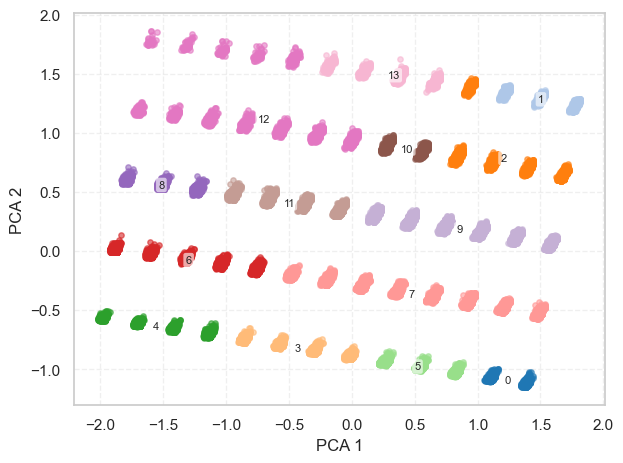

In [96]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=300,
    min_samples=10,
    metric='euclidean',
    cluster_selection_epsilon=0.3,
    cluster_selection_method='eom',
    prediction_data=True
)
cluster_labels = clusterer.fit_predict(shap_val_values_2d)

unique_clusters = np.unique(cluster_labels)

plt.figure()

unique_clusters = np.unique(cluster_labels)
unique_clusters = unique_clusters[unique_clusters != -1]

cmap = plt.get_cmap('tab20')

noise_mask = (cluster_labels == -1)
plt.scatter(
    shap_val_values_2d[noise_mask, 0], shap_val_values_2d[noise_mask, 1],
    color="black", alpha=0.6, s=15, marker='x', label="Noise"
)

for i, cluster_id in enumerate(unique_clusters):
    c_mask = (cluster_labels == cluster_id)
    color = cmap(i % 20)
    
    plt.scatter(
        shap_val_values_2d[c_mask, 0], shap_val_values_2d[c_mask, 1],
        color=color, alpha=0.6, s=15, label=f'Cluster {cluster_id}'
    )
    
    c_x = np.mean(shap_val_values_2d[c_mask, 0])
    c_y = np.mean(shap_val_values_2d[c_mask, 1])
    
    txt = plt.text(
        c_x, c_y, str(cluster_id), fontsize=8, 
        ha='center', va='center',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2')
    )

plt.xlabel("PCA 1", fontsize=12)
plt.ylabel("PCA 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)


plt.tight_layout()
plt.show()

In [98]:
unique_clusters = np.unique(cluster_labels)

header = f"{'ID':<6} | {'Size':<6} | {'Pos F2':<8} | {'Neg F2':<8} | {'W F2':<8} | {'TP':<4} | {'TN':<4} | {'FP':<4} | {'FN':<4}"
print("=" * len(header))
print(header)
print("-" * len(header))

for c in unique_clusters:
    mask = (cluster_labels == c)
    cluster_size = np.sum(mask)
    
    if cluster_size == 0:
        continue

    pos_rate = np.mean(y_val[mask])
    neg_rate = 1.0 - pos_rate

    pos_f2 = fbeta_score(y_val[mask], y_val_pred[mask], beta=2, pos_label=1)
    neg_f2 = fbeta_score(y_val[mask], y_val_pred[mask], beta=2, pos_label=0)

    w_f2 = (pos_rate * pos_f2) + (neg_rate * neg_f2)
        
    tn, fp, fn, tp = confusion_matrix(y_val[mask], y_val_pred[mask]).ravel()
        
    cluster_id_str = str(c) if c != -1 else "Noise"
    print(f"{cluster_id_str:<6} | {cluster_size:<6} | {pos_f2:<8.2%} | {neg_f2:<8.2%} | {w_f2:<8.2%} | {tp:<4} | {tn:<4} | {fp:<4} | {fn:<4}")

print("=" * len(header))

ID     | Size   | Pos F2   | Neg F2   | W F2     | TP   | TN   | FP   | FN  
----------------------------------------------------------------------------
0      | 778    | 35.95%   | 76.65%   | 73.62%   | 33   | 526  | 194  | 25  
1      | 625    | 78.85%   | 0.00%    | 33.69%   | 267  | 0    | 358  | 0   
2      | 2674   | 68.19%   | 0.53%    | 20.83%   | 801  | 8    | 1864 | 1   
3      | 2987   | 0.00%    | 99.82%   | 98.92%   | 0    | 2960 | 0    | 27  
4      | 2821   | 0.00%    | 99.95%   | 99.70%   | 0    | 2814 | 0    | 7   
5      | 2258   | 9.23%    | 97.31%   | 94.77%   | 6    | 2134 | 59   | 59  
6      | 5731   | 0.00%    | 99.89%   | 99.35%   | 0    | 5700 | 0    | 31  
7      | 12060  | 35.94%   | 81.29%   | 78.39%   | 429  | 8833 | 2456 | 342 
8      | 2382   | 0.00%    | 99.85%   | 99.09%   | 0    | 2364 | 0    | 18  
9      | 8726   | 49.22%   | 34.94%   | 37.01%   | 1120 | 2254 | 5210 | 142 
10     | 1323   | 50.12%   | 13.11%   | 19.29%   | 208  | 119  | 983  | 13  